# Notebook 5 — The Pretraining Loop
**Adapted for Jupyter Notebook / Kubeflow**

Loads the model from Notebook 4 and the packed dataset from Notebook 3,
configures the HuggingFace `Trainer`, runs 30 pretraining steps, and
plots the training loss curve.

**Requires:**
- `./data/SmolLM2-26L-pruned-init/` — from Notebook 4
- `./data/packaged_pretrain_dataset.parquet` — from Notebook 3

**Learning objectives:**
1. Understand the next-token prediction training objective
2. Configure training hyperparameters using `TrainingArguments`
3. Run a pretraining loop and monitor loss
4. Plot and interpret the training curve

In [1]:
import warnings
warnings.filterwarnings("ignore")
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "transformers", "torch", "datasets", "-q"])

CompletedProcess(args=['C:\\Users\\om751\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', '-m', 'pip', 'install', 'transformers', 'torch', 'datasets', '-q'], returncode=0)

In [2]:
import os
import torch

# ── Data directory ────────────────────────────────────────────────────
data_dir = "./data"

# ── File existence check ──────────────────────────────────────────────
model_path  = os.path.join(data_dir, "SmolLM2-26L-pruned-init")
packed_path = os.path.join(data_dir, "packaged_pretrain_dataset.parquet")

print("File check:")
print(f"  SmolLM2-26L-pruned-init/             : {'✅ EXISTS' if os.path.isdir(model_path) else '❌ NOT FOUND — run Notebook 4 first'}")
print(f"  packaged_pretrain_dataset.parquet    : {'✅ EXISTS' if os.path.exists(packed_path) else '❌ NOT FOUND — run Notebook 3 first'}")

def fix_torch_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

fix_torch_seed()
print(f"\nPyTorch : {torch.__version__}")
print(f"Device  : {'GPU — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

File check:
  SmolLM2-26L-pruned-init/             : ✅ EXISTS
  packaged_pretrain_dataset.parquet    : ✅ EXISTS

PyTorch : 2.11.0+cpu
Device  : CPU


## 1. Load the Model

We load the depth-pruned SmolLM2 checkpoint saved by Notebook 4.

**Why `use_cache=False`?**
Gradient checkpointing (used to save memory during training) is incompatible with the KV-cache.
Always set `use_cache=False` when `gradient_checkpointing=True`.

In [3]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="cpu",
    torch_dtype=torch.bfloat16,
    use_cache=False,   # required for gradient checkpointing
)

nparams = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded")
print(f"Architecture : {model.config.model_type}")
print(f"Layers       : {model.config.num_hidden_layers}")
print(f"Hidden size  : {model.config.hidden_size}")
print(f"Parameters   : {nparams:,}  (~{nparams/1e6:.0f}M)")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

✅ Model loaded
Architecture : llama
Layers       : 30
Hidden size  : 960
Parameters   : 342,156,480  (~342M)


## 2. Load the Packed Dataset

We wrap the Parquet file in a PyTorch `Dataset` class.

**Why `input_ids == labels`?**
In causal language modelling, each token's label is the next token in the sequence.
The Trainer shifts labels internally, so we pass the same tensor for both.

```
Token stream : [BOS]  The  cat  sat  on  the  mat  [EOS]
Input        : [BOS]  The  cat  sat  on  the  mat
Labels       :  The   cat  sat  on  the  mat  [EOS]
```

In [4]:
import datasets
from torch.utils.data import Dataset
import torch.nn.functional as F

class CustomDataset(Dataset):
    def __init__(self, args, split="train"):
        self.max_seq_length = args.max_seq_length
        self.dataset        = datasets.load_dataset(
            "parquet", data_files=args.dataset_name, split=split
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        input_ids  = torch.LongTensor(self.dataset[idx]["input_ids"])
        input_ids  = input_ids[:self.max_seq_length]
        pad_length = self.max_seq_length - len(input_ids)
        if pad_length > 0:
            input_ids = F.pad(input_ids, (0, pad_length), value=0)
        labels = input_ids.clone()
        return {"input_ids": input_ids, "labels": labels}

print("✅ CustomDataset class defined")

✅ CustomDataset class defined


## 3. Configure Training Arguments

All hyperparameters are defined in one `CustomArguments` dataclass.

| Parameter | Value | Why |
|---|---|---|
| `max_steps` | 30 | Small for demo — real runs use millions |
| `per_device_train_batch_size` | 2 | Sequences per step |
| `learning_rate` | 5e-5 | Standard starting LR for continued pretraining |
| `warmup_steps` | 10 | LR ramps from 0 → 5e-5 over first 10 steps to prevent loss explosion |
| `weight_decay` | 0.01 | L2 regularisation — keeps weights small and general |
| `gradient_checkpointing` | True | Recompute activations to save memory |
| `bf16` | False | CPU only — bfloat16 requires Ampere GPU |
| `logging_steps` | 3 | Log loss every 3 steps |

In [5]:
from dataclasses import dataclass, field
import transformers

@dataclass
class CustomArguments(transformers.TrainingArguments):
    dataset_name  : str   = field(default=packed_path)
    num_proc      : int   = field(default=1)
    max_seq_length: int   = field(default=32)      # must match Notebook 3 packing length

    seed          : int   = field(default=42)
    optim         : str   = field(default="adamw_torch")
    max_steps     : int   = field(default=30)
    per_device_train_batch_size: int = field(default=2)

    learning_rate : float = field(default=5e-5)
    weight_decay  : float = field(default=0.01)
    warmup_steps  : int   = field(default=10)
    lr_scheduler_type: str = field(default="linear")

    gradient_checkpointing    : bool  = field(default=True)
    bf16                      : bool  = field(default=False)   # CPU-safe: False
    gradient_accumulation_steps: int  = field(default=1)
    dataloader_num_workers    : int   = field(default=0)       # 0 = main process only (CPU-safe)

    logging_steps : int   = field(default=3)
    report_to     : str   = field(default="none")

print("✅ CustomArguments defined")

✅ CustomArguments defined


In [6]:
# Parse arguments — bf16=False for CPU / Kubeflow CPU-only nodes
parser = transformers.HfArgumentParser(CustomArguments)
args,  = parser.parse_args_into_dataclasses(
    args=["--output_dir", os.path.join(data_dir, "training_output"),
          "--bf16", "False"]
)

print(f"Output dir    : {args.output_dir}")
print(f"Dataset       : {args.dataset_name}")
print(f"Max steps     : {args.max_steps}")
print(f"Batch size    : {args.per_device_train_batch_size}")
print(f"Learning rate : {args.learning_rate}")
print(f"Warmup steps  : {args.warmup_steps}")
print(f"Precision     : {'bfloat16' if args.bf16 else 'float32 (CPU)'}")

Output dir    : ./data\training_output
Dataset       : ./data\packaged_pretrain_dataset.parquet
Max steps     : 30
Batch size    : 2
Learning rate : 5e-05
Warmup steps  : 10
Precision     : float32 (CPU)


In [7]:
# Instantiate dataset and verify shape
train_dataset = CustomDataset(args=args)

print(f"Total packed sequences : {len(train_dataset):,}")
print(f"Shape of one sample    : {train_dataset[0]['input_ids'].shape}")
print(f"\nFirst 10 token IDs of sample[0]:")
print(train_dataset[0]["input_ids"][:10])

Total packed sequences : 2,162
Shape of one sample    : torch.Size([32])

First 10 token IDs of sample[0]:
tensor([    0,  6014,    90, 15037,   787,   717,  1727,   105,  5484,   216])


## 4. Run the Trainer

### 4a. Loss Logging Callback

The training objective is cross-entropy loss:

```
Loss = −log P(correct next token)
```

- Random model (vocab 49,152): starting loss ≈ log(49,152) ≈ **10.8**
- Well-trained model on general text: loss ≈ **2–3**
- A **decreasing** loss curve confirms the model is learning

In [8]:
from transformers import Trainer, TrainerCallback

class LossLoggingCallback(TrainerCallback):
    """Captures training loss at each logging step."""
    def __init__(self):
        self.logs = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            self.logs.append(logs)

loss_logging_callback = LossLoggingCallback()
print("✅ Loss logging callback initialised")

✅ Loss logging callback initialised


### 4b. Run the Training Loop

In [9]:
# Verify sequence lengths are uniform
lengths = [len(train_dataset.dataset[i]["input_ids"])
           for i in range(min(20, len(train_dataset)))]
print(f"Sequence lengths (first 20): min={min(lengths)}, max={max(lengths)}")
print(f"max_seq_length set to: {args.max_seq_length}")

Sequence lengths (first 20): min=32, max=32
max_seq_length set to: 32


In [10]:
trainer = Trainer(
    model         = model,
    args          = args,
    train_dataset = train_dataset,
    eval_dataset  = None,
    callbacks     = [loss_logging_callback]
)

print(f"Starting pretraining — {args.max_steps} steps on {len(train_dataset):,} sequences\n")
trainer.train()
print("\n✅ Training complete")

Starting pretraining — 30 steps on 2,162 sequences



Step,Training Loss
3,3.939669
6,4.311210
9,4.519766
12,4.325597
15,4.136234
18,4.050261
21,4.618495
24,4.750326
27,4.196760
30,4.818343


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training complete


### 4c. Inspect Loss Values

In [11]:
print(f"{'Step':<10} {'Loss':<10}")
print("-" * 22)
for log in loss_logging_callback.logs:
    if "loss" in log:
        step = log.get("step", log.get("epoch", "?"))
        print(f"{str(step):<10} {log['loss']:<10.4f}")

Step       Loss      
----------------------
0.0027752081406105457 3.9397    
0.005550416281221091 4.3112    
0.008325624421831638 4.5198    
0.011100832562442183 4.3256    
0.013876040703052728 4.1362    
0.016651248843663275 4.0503    
0.01942645698427382 4.6185    
0.022201665124884366 4.7503    
0.02497687326549491 4.1968    
0.027752081406105456 4.8183    


### 4d. Plot the Training Curve

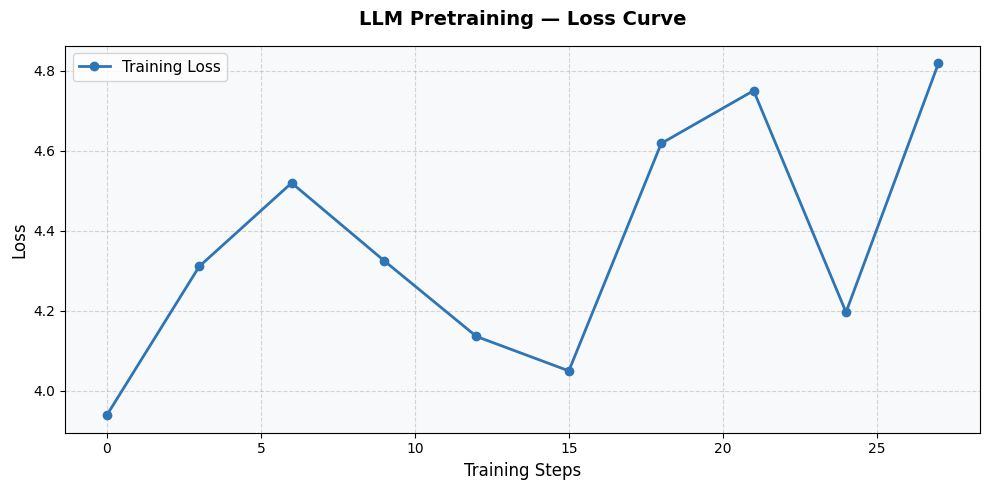

✅ Plot saved to: ./data\training_loss_curve.png


In [12]:
import matplotlib.pyplot as plt

training_logs = [log for log in loss_logging_callback.logs if "loss" in log]
steps      = [log.get("step", i * args.logging_steps) for i, log in enumerate(training_logs)]
train_loss = [log["loss"] for log in training_logs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, train_loss, marker="o", linewidth=2, color="#2E75B6", label="Training Loss")
ax.set_title("LLM Pretraining — Loss Curve", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Training Steps", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_facecolor("#F8F9FA")
fig.tight_layout()

plot_path = os.path.join(data_dir, "training_loss_curve.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved to: {plot_path}")

## 5. Save the Trained Model

In [13]:
trained_model_path = os.path.join(data_dir, "SmolLM2-26L-pretrained")
trainer.save_model(trained_model_path)
print(f"✅ Trained model saved to: {trained_model_path}")
print("Files:")
for f in sorted(os.listdir(trained_model_path)):
    size_kb = os.path.getsize(os.path.join(trained_model_path, f)) / 1024
    print(f"  {f:<45} {size_kb:.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Trained model saved to: ./data\SmolLM2-26L-pretrained
Files:
  config.json                                   0.8 KB
  generation_config.json                        0.1 KB
  model.safetensors                             668304.3 KB
  training_args.bin                             5.2 KB


## Summary

| Concept | Detail |
|---|---|
| Causal language modelling | Next-token prediction — label for each token is the next token |
| `input_ids == labels` | Trainer shifts labels internally; we pass the same tensor for both |
| Cross-entropy loss | Measures how wrong the model's next-token prediction is |
| Starting loss ~10.8 | log(49,152 vocab) — random model assigns equal probability to everything |
| LR warmup | Ramps LR from 0 → target over first N steps to prevent loss explosion |
| Gradient checkpointing | Trades compute for memory — recomputes activations during backward pass |
| `bf16=False` | Required on CPU — bfloat16 needs Ampere GPU |
| `dataloader_num_workers=0` | CPU-safe setting — avoids multiprocessing issues on Kubeflow |
| Output | `./data/SmolLM2-26L-pretrained/` — trained model checkpoint |
| Output | `./data/training_loss_curve.png` — loss curve plot |